<a href="https://colab.research.google.com/github/arturbernardo/eleicoes_fingerprint/blob/main/eleicoes_fingerprint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import drive
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.colors import LogNorm


In [51]:
pd.options.display.max_columns = None


In [ ]:
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
all = pd.DataFrame()

states = ['AC', 'AL', 'AM', 'AP', 'DF', 'ES', 'MA', 'MS', 'MG', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'SC', 'SE', 'ZZ', 'TO', 'SP', 'RS', 'CE', 'GO', 'BA']
# states = ['BA']

for state in states:
  st = pd.read_csv('/content/drive/MyDrive/data/eleicoes2022unziped/bweb_2t_'+state+'_311020221535.csv', encoding="ISO-8859-1", sep = ';',
                   dtype={
                            "SG_UF": pd.CategoricalDtype(),
                            "CD_MUNICIPIO": pd.Int64Dtype(),
                            "NR_LOCAL_VOTACAO": pd.Int64Dtype(),
                            "NR_ZONA": pd.Int64Dtype(),
                            "NR_SECAO": pd.CategoricalDtype()
                        })

  st_presidente = st[st.CD_CARGO_PERGUNTA == 1]
  filtered_df = st_presidente.loc[(st_presidente['NR_PARTIDO'] == 13) | (st_presidente['NR_PARTIDO'] == 22)]

  toUnion = [all, filtered_df]

  all = pd.concat(toUnion)

all


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,CD_PLEITO,DT_PLEITO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,SG_UF,CD_MUNICIPIO,NM_MUNICIPIO,NR_ZONA,NR_SECAO,NR_LOCAL_VOTACAO,CD_CARGO_PERGUNTA,DS_CARGO_PERGUNTA,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,DT_BU_RECEBIDO,QT_APTOS,QT_COMPARECIMENTO,QT_ABSTENCOES,CD_TIPO_URNA,DS_TIPO_URNA,CD_TIPO_VOTAVEL,DS_TIPO_VOTAVEL,NR_VOTAVEL,NM_VOTAVEL,QT_VOTOS,NR_URNA_EFETIVADA,CD_CARGA_1_URNA_EFETIVADA,CD_CARGA_2_URNA_EFETIVADA,CD_FLASHCARD_URNA_EFETIVADA,DT_CARGA_URNA_EFETIVADA,DS_CARGO_PERGUNTA_SECAO,DS_AGREGADAS,DT_ABERTURA,DT_ENCERRAMENTO,QT_ELEITORES_BIOMETRIA_NH,DT_EMISSAO_BU,NR_JUNTA_APURADORA,NR_TURMA_APURADORA
0,31/10/2022,15:35:43,2022,0,Eleição Ordinária,407,30/10/2022,2,545,Eleição Geral Federal 2022,AC,1392,RIO BRANCO,1,3,1279,1,Presidente,13,PT,Partido dos Trabalhadores,30/10/2022 17:34:43,185,147,38,1,APURADA,1,Nominal,13,LULA,48,2046404,428.953.752.256.007.171.,487.308,90FF9DFC,23/09/2022 08:44:00,1 - 3,#NULO#,30/10/2022 06:01:16,30/10/2022 15:00:59,9,30/10/2022 15:04:47,-1,-1
2,31/10/2022,15:35:43,2022,0,Eleição Ordinária,407,30/10/2022,2,545,Eleição Geral Federal 2022,AC,1392,RIO BRANCO,1,3,1279,1,Presidente,22,PL,Partido Liberal,30/10/2022 17:34:43,185,147,38,1,APURADA,1,Nominal,22,JAIR BOLSONARO,96,2046404,428.953.752.256.007.171.,487.308,90FF9DFC,23/09/2022 08:44:00,1 - 3,#NULO#,30/10/2022 06:01:16,30/10/2022 15:00:59,9,30/10/2022 15:04:47,-1,-1
4,31/10/2022,15:35:43,2022,0,Eleição Ordinária,407,30/10/2022,2,545,Eleição Geral Federal 2022,AC,1392,RIO BRANCO,1,4,1139,1,Presidente,22,PL,Partido Liberal,30/10/2022 17:25:33,339,259,80,1,APURADA,1,Nominal,22,JAIR BOLSONARO,167,2048249,984.509.427.112.588.751.,686.216,90FF9DFC,23/09/2022 09:34:00,1 - 4,#NULO#,30/10/2022 06:00:01,30/10/2022 15:01:55,13,30/10/2022 15:05:12,-1,-1
5,31/10/2022,15:35:43,2022,0,Eleição Ordinária,407,30/10/2022,2,545,Eleição Geral Federal 2022,AC,1392,RIO BRANCO,1,4,1139,1,Presidente,13,PT,Partido dos Trabalhadores,30/10/2022 17:25:33,339,259,80,1,APURADA,1,Nominal,13,LULA,83,2048249,984.509.427.112.588.751.,686.216,90FF9DFC,23/09/2022 09:34:00,1 - 4,#NULO#,30/10/2022 06:00:01,30/10/2022 15:01:55,13,30/10/2022 15:05:12,-1,-1
8,31/10/2022,15:35:43,2022,0,Eleição Ordinária,407,30/10/2022,2,545,Eleição Geral Federal 2022,AC,1392,RIO BRANCO,1,5,1031,1,Presidente,13,PT,Partido dos Trabalhadores,30/10/2022 17:28:42,341,260,81,1,APURADA,1,Nominal,13,LULA,72,2048064,984.509.533.412.818.797.,804.743,90FF9DFC,23/09/2022 09:46:00,1 - 5,#NULO#,30/10/2022 06:00:50,30/10/2022 15:02:23,8,30/10/2022 15:05:25,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269569,31/10/2022,15:48:51,2022,0,Eleição Ordinária,407,30/10/2022,2,545,Eleição Geral Federal 2022,BA,30007,LUÍS EDUARDO MAGALHÃES,205,210,1171,1,Presidente,13,PT,Partido dos Trabalhadores,30/10/2022 18:24:56,208,193,15,1,APURADA,1,Nominal,13,LULA,25,1016432,757.148.752.850.405.603.,152.278,D530864C,27/09/2022 16:42:00,1 - 210,#NULO#,30/10/2022 08:00:01,30/10/2022 17:00:25,11,30/10/2022 17:02:24,-1,-1
269574,31/10/2022,15:48:51,2022,0,Eleição Ordinária,407,30/10/2022,2,545,Eleição Geral Federal 2022,BA,30007,LUÍS EDUARDO MAGALHÃES,205,211,1309,1,Presidente,22,PL,Partido Liberal,30/10/2022 18:10:32,109,87,22,1,APURADA,1,Nominal,22,JAIR BOLSONARO,58,1075408,231.996.595.432.396.438.,158.553,96BD8C44,27/09/2022 20:26:00,1 - 211,#NULO#,30/10/2022 08:00:01,30/10/2022 17:11:29,11,30/10/2022 17:13:15,-1,-1
269576,31/10/2022,15:48:51,2022,0,Eleição Ordinária,407,30/10/2022,2,545,Eleição Geral Federal 2022,BA,30007,LUÍS EDUARDO MAGALHÃES,205,211,1309,1,Presidente,13,PT,Partido dos Trabalhadores,30/10/2022 18:10:32,109,87,22,1,APURADA,1,Nominal,13,LULA,27,1075408,231.996.595.432.396.438.,158.553,96BD8C44,27/09/2022 20:26:00,1 - 211,#NULO#,30/10/2022 08:00:01,30/10/2022 17:11:29,11,30/10/2022 17:13:15,-1,-1
269581,31/10/2022,15:48:51,20

In [45]:
df = all

In [48]:

# ANO_ELEICAO NR_TURNO CD_CARGO_PERGUNTA remover
key_cols = [
    "ANO_ELEICAO", "NR_TURNO", "SG_UF", "CD_MUNICIPIO",
    "NR_ZONA", "NR_SECAO", "NR_URNA_EFETIVADA", "CD_CARGO_PERGUNTA"
]

cols = key_cols + ["NR_PARTIDO", "QT_VOTOS", "QT_APTOS", "QT_COMPARECIMENTO"]

x = df.loc[df["NR_PARTIDO"].isin([13, 22]), cols]

for c in ["ANO_ELEICAO", "NR_TURNO", "CD_MUNICIPIO", "NR_ZONA",
          "NR_SECAO", "NR_URNA_EFETIVADA", "CD_CARGO_PERGUNTA",
          "NR_PARTIDO", "QT_VOTOS", "QT_APTOS", "QT_COMPARECIMENTO"]:
    x[c] = pd.to_numeric(x[c], downcast="integer")

x["SG_UF"] = x["SG_UF"].astype("category")

v13 = x.loc[x["NR_PARTIDO"] == 13, key_cols + ["QT_VOTOS", "QT_APTOS", "QT_COMPARECIMENTO"]]
v13 = v13.rename(columns={"QT_VOTOS": "votos_13"}).drop_duplicates(subset=key_cols)

v22 = x.loc[x["NR_PARTIDO"] == 22, key_cols + ["QT_VOTOS"]]
v22 = v22.rename(columns={"QT_VOTOS": "votos_22"}).drop_duplicates(subset=key_cols)

plot_df = v13.merge(v22, on=key_cols, how="inner")
plot_df["valid_votes_2cand"] = plot_df["votos_13"] + plot_df["votos_22"]
# plot_df["winner_votes"] = plot_df[["votos_13", "votos_22"]].max(axis=1)
plot_df["winner_votes"] = plot_df["votos_13"]
# plot_df["winner_votes"] = plot_df["votos_22"]
plot_df = plot_df[(plot_df["QT_APTOS"] > 0) & (plot_df["valid_votes_2cand"] > 0)]

# plot_df["turnout_pct"] = plot_df["QT_COMPARECIMENTO"] / plot_df["QT_APTOS"] * 100
plot_df["turnout_pct"] = plot_df["votos_13"] / plot_df["QT_APTOS"] * 100
# plot_df["turnout_pct"] = plot_df["votos_22"] / plot_df["QT_APTOS"] * 100
plot_df["winner_pct"] = plot_df["winner_votes"] / plot_df["valid_votes_2cand"] * 100

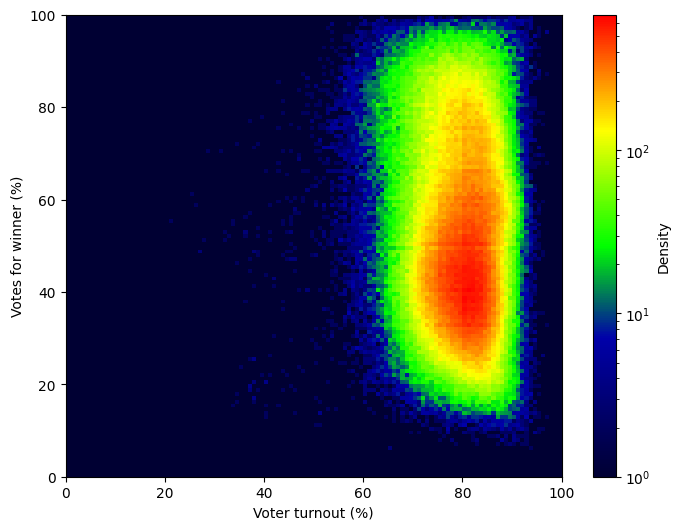

In [52]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm

colors = [
    (0.0, "#000033"),   # azul bem escuro (fundo)
    (0.3, "#0000AA"),   # azul
    (0.5, "#00FF00"),   # verde
    (0.75, "#FFFF00"),  # amarelo (transição)
    (1.0, "#FF0000")    # vermelho
]

cmap = LinearSegmentedColormap.from_list("blue_green_red", colors)


# adapta para a estrutura do exemplo sintético
fingerprint_df = plot_df.rename(columns={
    "QT_APTOS": "registered_voters",
    "QT_COMPARECIMENTO": "ballots_cast",
    "valid_votes_2cand": "valid_votes",
    "winner_votes": "winner_votes"
})[["registered_voters", "ballots_cast", "valid_votes", "winner_votes"]].copy()

fingerprint_df["turnout_pct"] = (
    fingerprint_df["ballots_cast"] / fingerprint_df["registered_voters"] * 100
)

fingerprint_df["winner_pct"] = (
    fingerprint_df["winner_votes"] / fingerprint_df["valid_votes"] * 100
)

fingerprint_df = fingerprint_df[
    (fingerprint_df["registered_voters"] > 0) &
    (fingerprint_df["valid_votes"] > 0)
].copy()

plt.figure(figsize=(8, 6))
plt.hist2d(
    fingerprint_df["turnout_pct"],
    fingerprint_df["winner_pct"],
    bins=120,
    range=[[0, 100], [0, 100]],
    cmap=cmap,
    norm=LogNorm()
)
plt.colorbar(label="Density")
plt.xlabel("Voter turnout (%)")
plt.ylabel("Votes for winner (%)")
plt.xlim(0, 100)
plt.ylim(0, 100)

plt.gca().set_facecolor("#000033")

plt.show()

In [ ]:
fingerprint_df["turnout_pct"]

,turnout_pct
0,78.440367
1,77.802198
2,77.362637
3,80.637813
4,77.038627
...,...
22783,82.985075
22784,83.918129
22785,85.496183
22786,84.057971


In [ ]:
fingerprint_df["winner_pct"]

,winner_pct
0,55.589124
1,53.602305
2,53.254438
3,51.453488
4,51.296830
...,...
22783,53.053435
22784,63.503650
22785,57.547170
22786,59.649123


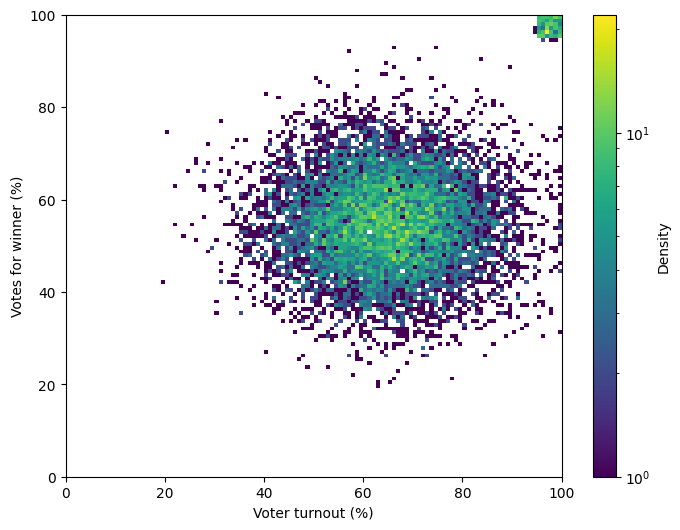

In [ ]:


np.random.seed(42)

n = 10000

registered_voters = np.random.randint(200, 2000, size=n)
turnout_pct = np.clip(np.random.normal(65, 12, size=n), 20, 100)
ballots_cast = (registered_voters * turnout_pct / 100).astype(int)

winner_pct = np.clip(np.random.normal(55, 10, size=n), 20, 100)
valid_votes = ballots_cast
winner_votes = (valid_votes * winner_pct / 100).astype(int)

df = pd.DataFrame({
    "registered_voters": registered_voters,
    "ballots_cast": ballots_cast,
    "valid_votes": valid_votes,
    "winner_votes": winner_votes
})

# Injeta um grupo artificial no canto superior direito
m = 300
fraud_idx = np.random.choice(df.index, size=m, replace=False)
df.loc[fraud_idx, "ballots_cast"] = (df.loc[fraud_idx, "registered_voters"] * np.random.uniform(0.95, 1.0, size=m)).astype(int)
df.loc[fraud_idx, "valid_votes"] = df.loc[fraud_idx, "ballots_cast"]
df.loc[fraud_idx, "winner_votes"] = (df.loc[fraud_idx, "valid_votes"] * np.random.uniform(0.95, 1.0, size=m)).astype(int)

df["turnout_pct"] = df["ballots_cast"] / df["registered_voters"] * 100
df["winner_pct"] = df["winner_votes"] / df["valid_votes"] * 100

plt.figure(figsize=(8, 6))
plt.hist2d(
    df["turnout_pct"],
    df["winner_pct"],
    bins=120,
    range=[[0, 100], [0, 100]],
    norm=LogNorm()
)
plt.colorbar(label="Density")
plt.xlabel("Voter turnout (%)")
plt.ylabel("Votes for winner (%)")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.show()

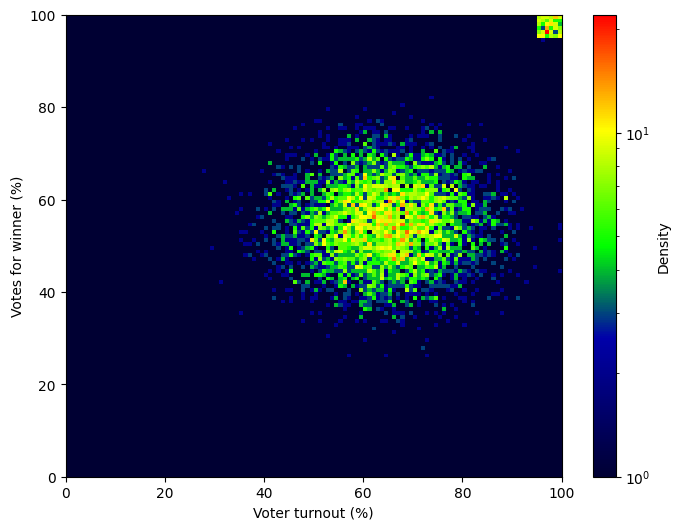

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm

# colormap customizado
colors = [
    (0.0, "#000033"),   # azul bem escuro (fundo)
    (0.3, "#0000AA"),   # azul
    (0.5, "#00FF00"),   # verde
    (0.75, "#FFFF00"),  # amarelo (transição)
    (1.0, "#FF0000")    # vermelho
]

cmap = LinearSegmentedColormap.from_list("blue_green_red", colors)

# exemplo usando seu dataframe df já preparado
plt.figure(figsize=(8, 6))

plt.hist2d(
    df["turnout_pct"],
    df["winner_pct"],
    bins=120,
    range=[[0, 100], [0, 100]],
    cmap=cmap,
    norm=LogNorm()
)

plt.colorbar(label="Density")
plt.xlabel("Voter turnout (%)")
plt.ylabel("Votes for winner (%)")
plt.xlim(0, 100)
plt.ylim(0, 100)

# fundo azul escuro mesmo fora do histograma
plt.gca().set_facecolor("#000033")

plt.show()